## Time-series Forecasting Using Facebook Prophet Package

Forecasting is a technique that is used for a variety of different purposes and situations such as sales forecasting, operational and budget planning etc. Similarly there are a variety of different techniques such as moving averages, smoothening, ARIMA etc to statistically make a forecast.

In [4]:
!pip install prophet

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from prophet import Prophet
import seaborn as sns
import pandas as pd
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [6]:
fd = sns.load_dataset('flights')
fd.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [7]:
fd = fd. loc[ :, ['passengers' ]]
fd.head()

,passengers
0,112
1,118
2,132
3,129
4,121


In [8]:
months = pd.date_range('19490101',periods=144, freq ='M')
months
fd['ds' ] = months
fd.head()
fd.dtypes

passengers             int64
ds            datetime64[ns]
dtype: object

In [9]:
fd = fd.rename(columns= {"passengers": "y"})
fd = fd.sort_index(axis=1)
#fd.y = np. Log(fd.y)
fd.head(5)

,ds,y
0,1949-01-31,112
1,1949-02-28,118
2,1949-03-31,132
3,1949-04-30,129
4,1949-05-31,121


In [10]:
my_forecast = Prophet(interval_width=0.95)

my_forecast. fit(fd)

10:36:04 - cmdstanpy - INFO - Chain [1] start processing
10:36:05 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
forecast_periods = my_forecast.make_future_dataframe(periods=36, include_history=True, freq='M')
forecast_periods

,ds
0,1949-01-31
1,1949-02-28
2,1949-03-31
3,1949-04-30
4,1949-05-31
...,...
175,1963-08-31
176,1963-09-30
177,1963-10-31
178,1963-11-30


In [12]:
forecast = my_forecast. predict(forecast_periods)
forecast1 = forecast . loc[ :, ['ds', 'yhat' ]]
forecast1.head()

,ds,yhat
0,1949-01-31,84.606556
1,1949-02-28,77.012695
2,1949-03-31,110.472816
3,1949-04-30,108.062053
4,1949-05-31,111.391434


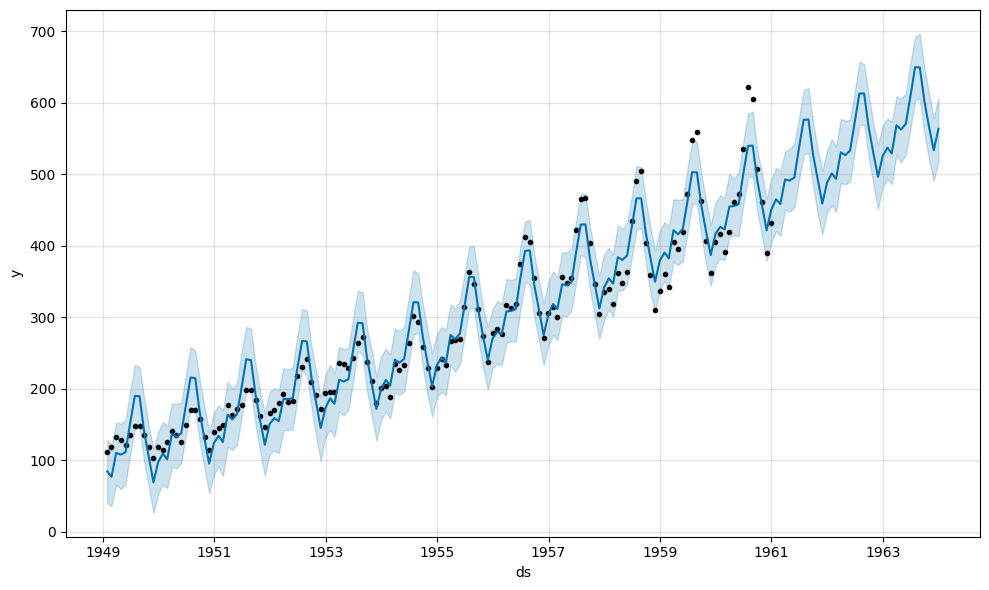

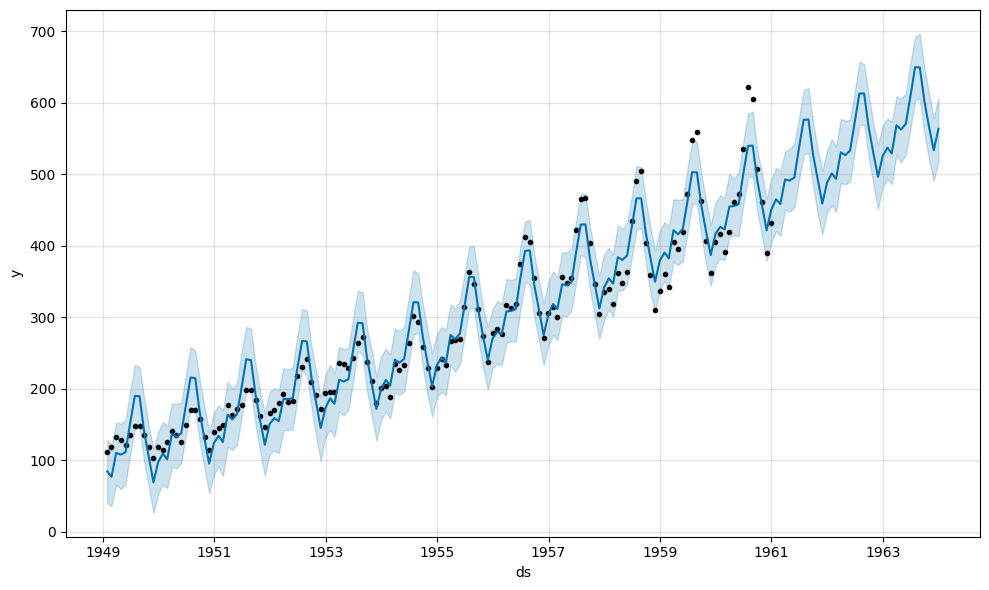

In [13]:
my_forecast.plot(forecast,
uncertainty=True)

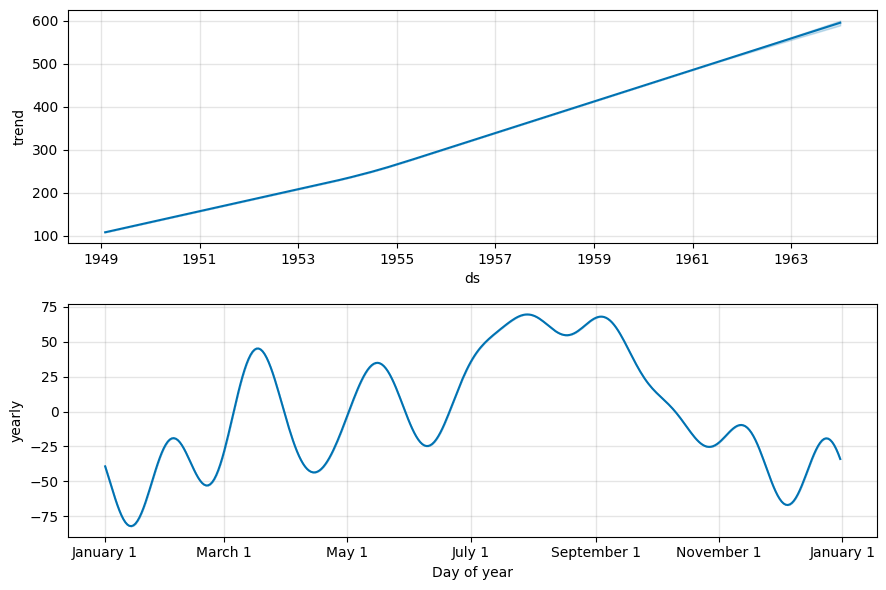

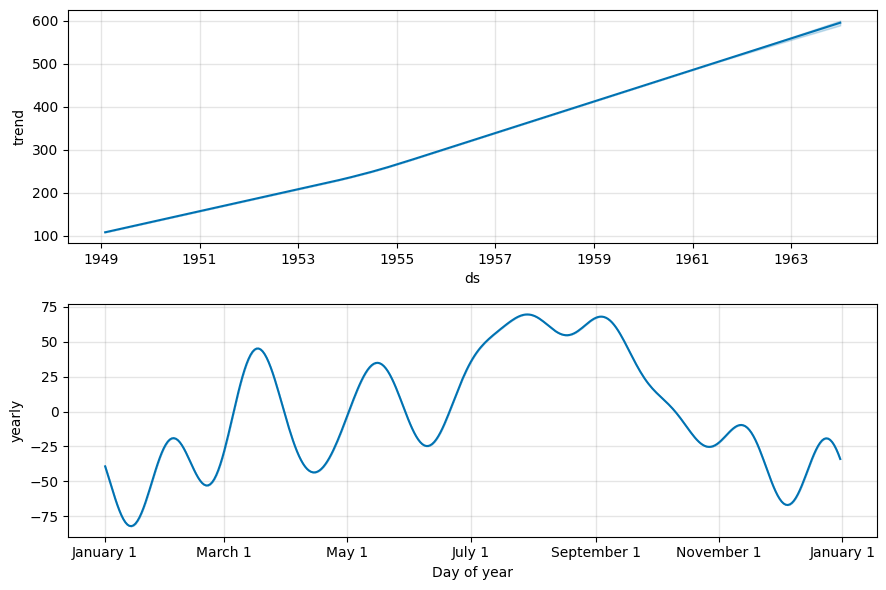

In [14]:
my_forecast. plot_components (forecast)

In [15]:
final_df = pd.merge(forecast1, fd, on ='ds', how = 'inner')
final_df.head()

,ds,yhat,y
0,1949-01-31,84.606556,112
1,1949-02-28,77.012695,118
2,1949-03-31,110.472816,132
3,1949-04-30,108.062053,129
4,1949-05-31,111.391434,121


In [16]:
import numpy as np
from sklearn import metrics
np.round(metrics.mean_absolute_error(final_df.yhat, final_df.y),0)

np.float64(17.0)

In [17]:
fd.head()

,ds,y
0,1949-01-31,112
1,1949-02-28,118
2,1949-03-31,132
3,1949-04-30,129
4,1949-05-31,121


In [18]:
fd.y = np.log(fd.y)
fd.head(5)

,ds,y
0,1949-01-31,4.718499
1,1949-02-28,4.770685
2,1949-03-31,4.882802
3,1949-04-30,4.859812
4,1949-05-31,4.795791


10:36:10 - cmdstanpy - INFO - Chain [1] start processing
10:36:10 - cmdstanpy - INFO - Chain [1] done processing


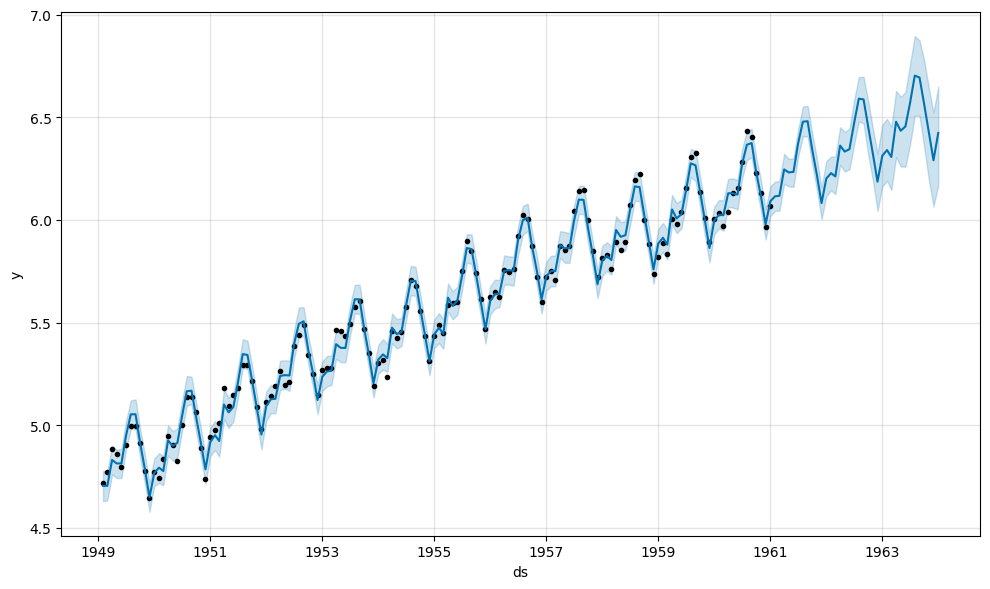

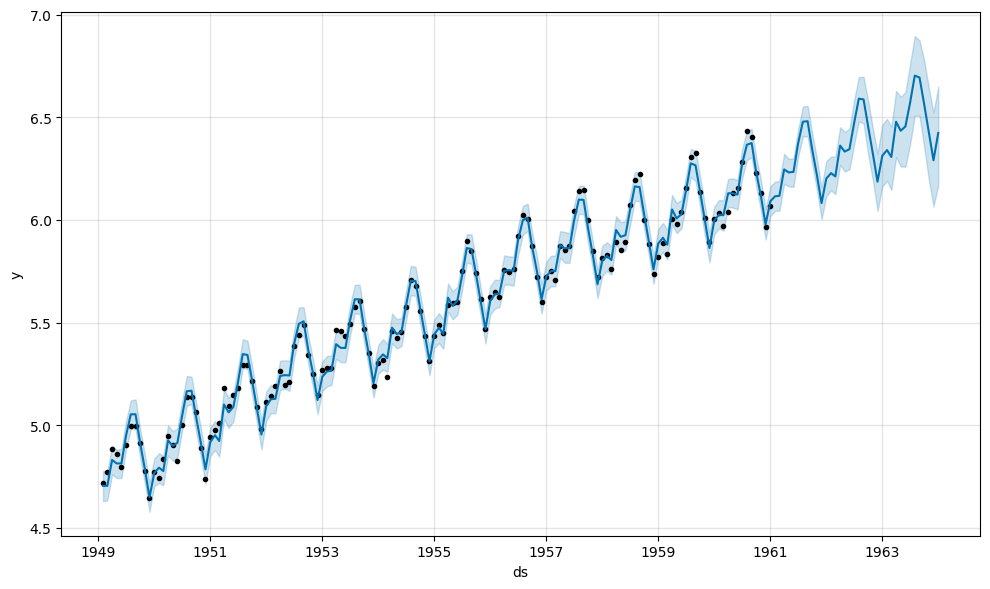

In [19]:
my_forecast = Prophet(interval_width=0.95)
my_forecast. fit(fd)
forecast_periods = my_forecast.make_future_dataframe(periods=36, include_history=True, freq='M')
forecast_periods
forecast = my_forecast. predict(forecast_periods)
forecast1 = forecast . loc[ :, ['ds', 'yhat' ]]
forecast1.head()
my_forecast. plot(forecast,
uncertainty=True)

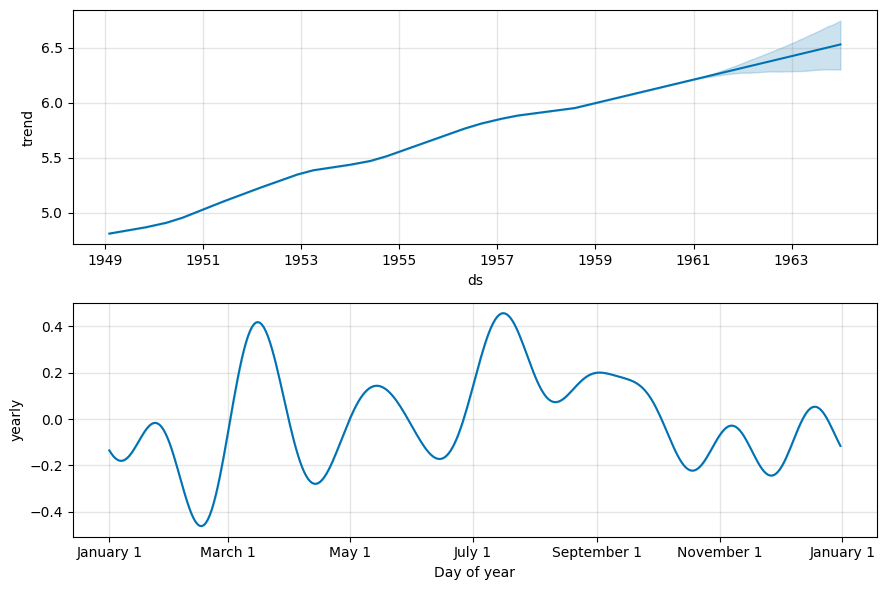

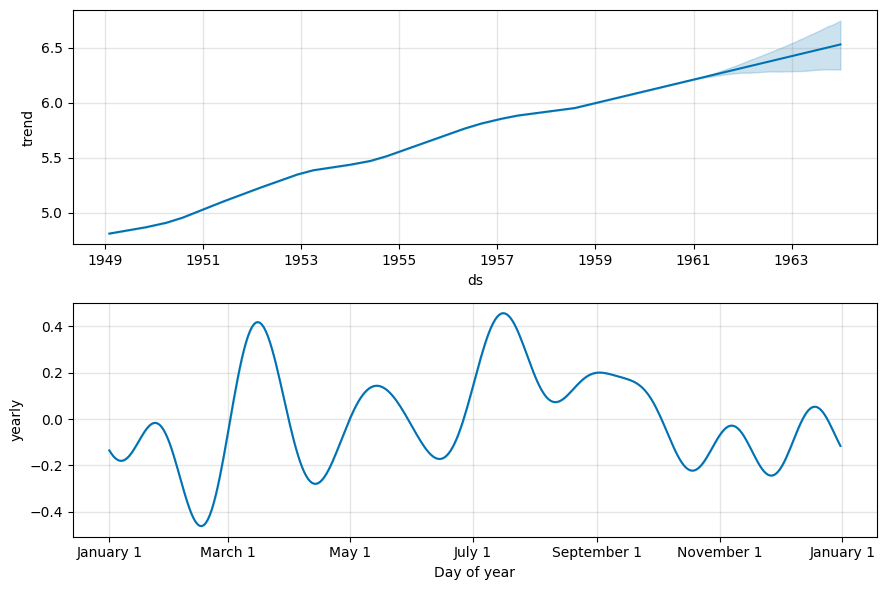

In [20]:
my_forecast.plot_components(forecast)

,ds,yhat,y
0,1949-01-31,4.705360,4.718499
1,1949-02-28,4.705032,4.770685
2,1949-03-31,4.831203,4.882802
3,1949-04-30,4.814257,4.859812
4,1949-05-31,4.814494,4.795791


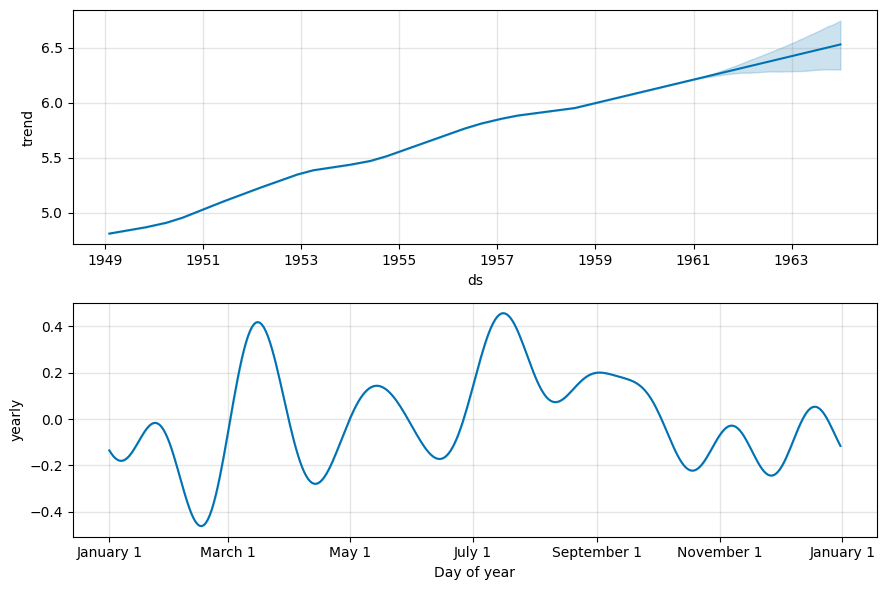

In [21]:
my_forecast.plot_components(forecast)
final_df1 = pd.merge(forecast1, fd, on ='ds', how = 'inner')
final_df1.head()

In [22]:
final_df1.yhat = np.e ** (final_df1.yhat)
final_df1.y = np.e ** (final_df1.y)
final_df1.head()

,ds,yhat,y
0,1949-01-31,110.538046,112.0
1,1949-02-28,110.501830,118.0
2,1949-03-31,125.361737,132.0
3,1949-04-30,123.255256,129.0
4,1949-05-31,123.284465,121.0


In [23]:
import numpy as np
from sklearn import metrics
np.round(metrics.mean_absolute_error(final_df1.yhat, final_df1.y),0)

np.float64(8.0)

In [24]:
final_df1.head()

,ds,yhat,y
0,1949-01-31,110.538046,112.0
1,1949-02-28,110.501830,118.0
2,1949-03-31,125.361737,132.0
3,1949-04-30,123.255256,129.0
4,1949-05-31,123.284465,121.0


In [25]:
final_df1.tail()

,ds,yhat,y
139,1960-08-31,587.155504,606.0
140,1960-09-30,509.244516,508.0
141,1960-10-31,452.654876,461.0
142,1960-11-30,394.854599,390.0
143,1960-12-31,442.062803,432.0


In [26]:
forecast2 = forecast . loc[144:, ['ds', 'yhat', 'yhat_lower', 'yhat_upper' ]]
forecast2. yhat = np.e ** (forecast2. yhat)
forecast2.yhat_lower = np.e ** (forecast2. yhat_lower)
forecast2.yhat_upper = np.e ** (forecast2.yhat_upper)
np.round(forecast2,0)

,ds,yhat,yhat_lower,yhat_upper
144,1961-01-31,453.0,422.0,487.0
145,1961-02-28,454.0,422.0,488.0
146,1961-03-31,516.0,481.0,557.0
147,1961-04-30,509.0,475.0,543.0
148,1961-05-31,510.0,474.0,545.0
149,1961-06-30,585.0,548.0,626.0
150,1961-07-31,651.0,607.0,701.0
151,1961-08-31,653.0,606.0,704.0
152,1961-09-30,569.0,529.0,616.0
153,1961-10-31,502.0,466.0,543.0


In [27]:
sns. tsplot(forecast2.yhat)
plt.show()

AttributeError: module 'seaborn' has no attribute 'tsplot'